# Example of using inpainting to compute matched-filters

This example demonstrates how we can use data we used for our premerger search and compute matched-filters where we use inpainting to deal with gaps.

* Because this is a premerger search we assume a gap at the end (in the example, 7 days before the signal mergers). While we do have data for that period, this is equivalent to padding the data with 7 days of 0s and then inpainting over those days. This then forms an alternative for our previous zero-latency filter.
* We add in two gaps earlier in the data, which is not possible to handle with the zero-latency filter.

In [2]:
import pycbc
import copy
import json
import numpy as np
import pycbc.types
from pycbc.types import MultiDetOptionAction
import pycbc.psd
import pycbc.filter
from pycbc.psd.lisa_pre_merger import generate_pre_merger_psds

from pycbc.waveform.pre_merger_waveform import (
    pre_process_data_lisa_pre_merger,
    generate_waveform_lisa_pre_merger,
)


from matplotlib import pyplot as plt

plt.style.use('../paper.mplstyle')

## Data files

This cell reads in data files. You can use a different PSD or signal number ... Noting that the 'pessimistic' PSD causes numerical issues because it (and the data produced from it) tends to infinite power as the frequency goes to 0. You can find the data files here https://github.com/icg-gravwaves/lisa_premerger_paper

In [3]:
# We need to have https://github.com/icg-gravwaves/lisa_premerger_paper/
# checked out
premerger_paper_location = '/Users/iwharry/Work/LISA/lisa_premerger_paper'


# Read data and PSD

psdname = 'optimistic'
signumber = '0'
data_length = 2592000
zeroed_length = 2**20
sample_rate = 0.2
flen = int(zeroed_length) // 2 + 1
delta_f = 1 / (2**20 * 5)
delta_t = 1 / sample_rate

data = pycbc.types.timeseries.load_timeseries(
        f'{premerger_paper_location}/Data/data_files/data_{psdname}_psd/signal_{signumber}.hdf',
        group=f"/LISA_A",
)
data._delta_t = 5 # Apparently it is not exactly this in the file, causing issues.
data_orig = data.copy()
data.resize(zeroed_length)

data_nonoise = pycbc.types.timeseries.load_timeseries(
        f'{premerger_paper_location}/Data/data_files/data_{psdname}_psd/signal_zero_noise_{signumber}.hdf',
        group=f"/LISA_A",
)
data_nonoise._delta_t = 5 # Apparently it is not exactly this in the file, causing issues.
data_nonoise.resize(zeroed_length)

psd = pycbc.psd.from_txt(f'{premerger_paper_location}/PSD_Files/model_AE_TDI1_SMOOTH_optimistic.txt.gz',
                        flen, delta_f, delta_f, is_asd_file=False
)

# I'm on the fence as to whether we should apply spectrum truncation ... Probably we should for safety(??)
#psd = pycbc.psd.inverse_spectrum_truncation(psd, 86400//5, delta_f, trunc_method='hann')

invpsd = 1./psd # Used for inpainting
invpsd[0] = 0 # Cannot have a DC component

/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


## Define function for doing inpainting between indexes

Can also give end_idx = len(data) to inpaint up until the end of a dataset.

In [5]:
# Having written this and then removed a bunch of unneeded stuff, I think this function is now redundant with `gate_and_paint` itself!
def inpaint_data(data, invpsd, start_idx, end_idx, copy=True):
    data = data.copy() if copy else data
    from pycbc.strain.gate import gate_and_paint
    return gate_and_paint(data, start_idx, end_idx, invpsd, copy=False)


    # gated_data = data.gate(merger_time - sev_days + gap/2., gap/2., method='paint', invpsd=invpsd)

## Create inpainted datasets

You can play about with this as you want. This example is a 7-days before merger signal, and then we add two gaps 14 and 21 days before merger.

**WARNING** The inpainting is a numerical matrix solver and therefore requires that solution to be numerically stable. For some cases (e.g. the unrealistic "pessimistic" PSD) this doesn't seem to be the case and the inpainting produces artefacts. The "optimistic" PSD seems to be stable, but some exploration of where this does, and doesn't, break down would be useful. (In addition to anything we can do to improve stability if this is a problem)

In [6]:
# Prepare the data (or datasets)
merger_time = 1931852406.9997194 # This is dependent on signum, should automate getting this value!
gate1_centre = merger_time - 86400*10
gate2_centre = merger_time - 86400*20

data_start = data.start_time
data_end = data.end_time
# Inpaint the end of the data
lindex = data_length//5 - 86400*7 // 5
rindex = data_length//5
data_inpaintend = inpaint_data(data, invpsd, lindex, rindex)
data_nonoise_inpaintend = inpaint_data(data_nonoise, invpsd, lindex, rindex)

# Add the gaps
lindex = int(float(gate1_centre - data.start_time) // 5)  - 86400//(5*2)
rindex = int(float(gate1_centre - data.start_time) // 5)  + 86400//(5*2)
print(lindex, rindex)
data_inpaintendandgaps = inpaint_data(data_inpaintend, invpsd, lindex, rindex)
data_nonoise_inpaintendandgaps = inpaint_data(data_nonoise_inpaintend, invpsd, lindex, rindex)

lindex = int(float(gate2_centre - data.start_time) // 5)  - 86400//(5*2)
rindex = int(float(gate2_centre - data.start_time) // 5)  + 86400//(5*2)
data_inpaintendandgaps = inpaint_data(data_inpaintendandgaps, invpsd, lindex, rindex)
data_nonoise_inpaintendandgaps = inpaint_data(data_nonoise_inpaintendandgaps, invpsd, lindex, rindex)



336750 354030


## How to compute (h|h) ?

So in theory computing `(h|h)` would ideally be done by inpainting a copy of `h` and then filtering that against an un-inpainted copy (I think). This would be extremely slow (even for search, let alone inference), so we don't want to do it.

Here we instead apply a hard cut on the time-domain representation of `h` and later compute `(h|h)` using that. I guess one could also set chunks of `h` in the frequency domain to 0, but this has the potential to cause issues. This seems to be one of the question marks over using inpainting. 

### Inference note

This operation can be done in the frequency domain (avoiding the need to do Fourier transforms), but it is a little tricksy. Basically one wants to correlate `|h(t)|^2|` with a mask containing the necessary 1s and 0s ... and we only want the 0th output of that correlation. This could be done in the frequency domain (by IFFTing `|h(t)|^2|` and IFFTing the mask). Issues are

* I don't think we can directly generate `|h(t)|^2|` in the frequency domain (though I imagine it wouldn't be hard for someone who knows waveform stuff to do this)
* The mask will be dependent on the `t_c` being used in the inference, so either we need to precompute and stask masks for different values of t_c (probably only needs to be `tc // sample_rate`), or we need to IFFT the mask every time.

I wonder if doing something similar to search and computing the time *dependent* `(h|s)` and `(h|h)` would be better here, and then marginalize over time explicitly. It may be as quick to get the time dependent series as the point values in this case ...

In [7]:
# Inpainting a waveform is expensive, can we do this differently?
# Time domain cutting is one option
data_nonoise_cutend = data_nonoise.copy()
# Cut the end of the data
lindex = data_length//5 - 86400*7 // 5
rindex = data_length//5
data_nonoise_cutend[lindex:rindex] = 0

# And cut the gaps
data_nonoise_cutendandgaps = data_nonoise_cutend.copy()
lindex = int(float(gate1_centre - data.start_time) // 5)  - 86400//(5*2)
rindex = int(float(gate1_centre - data.start_time) // 5)  + 86400//(5*2)
data_nonoise_cutendandgaps[lindex:rindex] = 0
lindex = int(float(gate2_centre - data.start_time) // 5)  - 86400//(5*2)
rindex = int(float(gate2_centre - data.start_time) // 5)  + 86400//(5*2)
data_nonoise_cutendandgaps[lindex:rindex] = 0


## Actually computing (h|s) and (h|h)

This function does the matched-filtering. Both `(h|s)(t)` and `(h|h)` are being computed here, though the function can be given `(h|h)` (or given `(h|h) = 1` to just return unnormalized `(h|s)(t)` ... For inference problems you don't want this as a function of time, so a different function would be used, but the principle is the same.

We remind that the gaps in the template only line up at `t=0` so for searching at any other time involves the gaps not quite lining up. For inference this is irrelevant, as you only search at a specific time, but for the search problem we'd need to be a bit careful about that (probably by computing `(h|s)` *without* cutting the waveform and then estimating a suitable `(h|h)` (which would be time-dependent, but hopefully not *strongly* time dependent ... Maybe the waveform would need to be cut at 7 days before merger even for `(h|s)`?) 



In [8]:
# Compute SNRs (equivalently one could do likelihoods here)
# Note that this function is computing both (h|s) and (h|h) though one can provide it (h|h) as a kwarg
snr1 = pycbc.filter.matched_filter(data_nonoise_inpaintendandgaps, data_inpaintendandgaps, psd)
snr2 = pycbc.filter.matched_filter(data_nonoise_inpaintend, data_inpaintend, psd)
snr3 = pycbc.filter.matched_filter(data_nonoise_cutendandgaps, data_inpaintendandgaps, psd)
snr4 = pycbc.filter.matched_filter(data_nonoise_cutend, data_inpaintend, psd)

# Move the peak away from 0 for ease of plotting
snr1.roll(10000)
snr2.roll(10000)
snr3.roll(10000)
snr4.roll(10000)


## Time-dependent (h|h)

Where we are computing a SNR time-series (as above), (h|h) would become time-dependent. Basically this relates to when the template overlaps the gaps in the data (This is discussed in the IAS paper first introducing this, see eqs 51 - 53). This does offer up an interesting possibility though: Can we filter a *full* waveform against data cut on the right hand side. As the waveform shifts to the left it corresponds to more and more time before merger. But because the normalization is right we can take a waveform and produce a SNR timeseries corresponding to the waveform shifting in time, correctly dealing with the gap. This means that we don't need to run searches at 7-days, 4-days, 1-day premerger etc. ... If we produce a suitable bank (details need investigating) we could simulataneously search at all times before merger (on a continuous scale).

Let's illustrate that.

### Computing the (h|h)(t)

We need to compute the quantity given in eq. 53 of the paper (PRD 104, 063034).

In [10]:
# Need to record when the data is zeroed out - Times are copied from before. Make sure this is consistent!

mask_end = np.ones(len(data_nonoise), dtype=float)
mask_endandgaps = np.ones(len(data_nonoise), dtype=float)
lindex = data_length//5 - 86400*7 // 5
rindex = data_length//5
mask_end[lindex:] = 0
mask_endandgaps[lindex:] = 0
lindex = int(float(gate1_centre - data.start_time) // 5)  - 86400//(5*2)
rindex = int(float(gate1_centre - data.start_time) // 5)  + 86400//(5*2)
mask_endandgaps[lindex:rindex] = 0
lindex = int(float(gate2_centre - data.start_time) // 5)  - 86400//(5*2)
rindex = int(float(gate2_centre - data.start_time) // 5)  + 86400//(5*2)
mask_endandgaps[lindex:rindex] = 0

# NOTE: We are using the *full* waveform here! We might want to cut at say 1 day (or 1 hour, or ...) pre-merger as we are focused on
#       premerger observations here.
data_to_use = data_nonoise.copy() 
# Cut the end of the data, OPTIONAL(?)
#lindex = data_length//5 - 86400*1 // 5
#rindex = data_length//5
#data_to_use[lindex:rindex] = 0
wform_shift = abs(data_to_use.data).argmax()
data_to_use.roll(-wform_shift)
maskts_end = pycbc.types.TimeSeries(mask_end, delta_t=data_to_use.delta_t, epoch=data_to_use._epoch, dtype=data_to_use.dtype)
maskts_endandgaps = pycbc.types.TimeSeries(mask_endandgaps, delta_t=data_to_use.delta_t, epoch=data_to_use._epoch, dtype=data_to_use.dtype)
maskfs_end = maskts_end.to_frequencyseries()
maskfs_endandgaps = maskts_endandgaps.to_frequencyseries()
datasq = (data_to_use.to_frequencyseries() * invpsd**0.5).to_timeseries()
datasq = datasq * datasq
masked_datafs_end = datasq.to_frequencyseries().conj() * maskfs_end
masked_datafts_end = masked_datafs_end.to_timeseries()
masked_datafs_endandgaps = datasq.to_frequencyseries().conj() * maskfs_endandgaps
masked_datafts_endandgaps = masked_datafs_endandgaps.to_timeseries()



### Visualising the `(h|h)` timeseries

First lots plot the whole thing. This looks weird because if the merger is in the available data `(h|h)` is huge, and if it's not
it is small. I show this on a semi-log scale to try to make it clearer, but maybe it makes things worse. Some features to highlight:

* The biggest values are when the merger is in the available data (unsurprisingly), and there's a massive drop off when it's not -> We know that the power here really accrues over a relatively short period of time.
* The orange (with gaps), shows clear drop offs
* At late times the value goes to 0 .. Indeed there is *no* waveform in band at this point, so this is numerical noise. ... The SNR timeseries will be invalid in this region because we're doing a 0/0 operation.
* In the zoomed in plot we see `(h|h)` rapidly decaying. This corresponds to less and less of the waveform being present in the data.
* The gaps make a small effect in the zoomed in plot, but there is a noticeable difference in power. This is more obvious if there is gap near the end of the available data.

(0.0, 100.0)

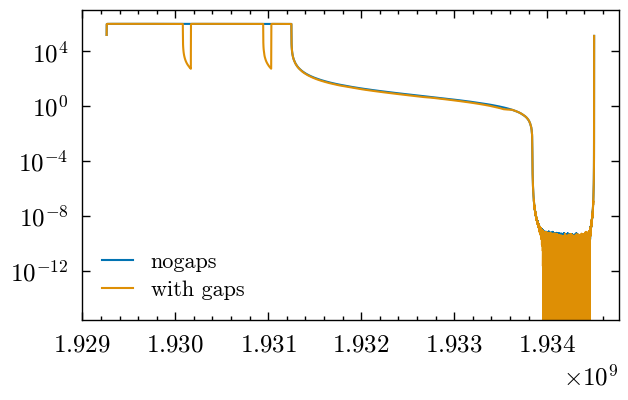

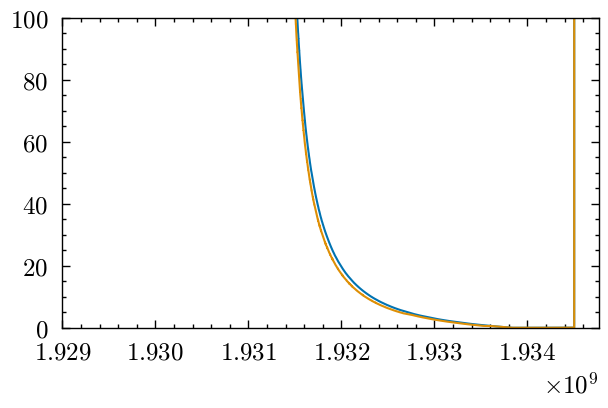

In [11]:
# Here's what the masks look like. Note the notches when we are dealing with gaps
plt.plot(masked_datafts_end.sample_times, masked_datafts_end, label='nogaps')
plt.semilogy(masked_datafts_end.sample_times, masked_datafts_endandgaps, label='with gaps')
plt.legend()

# Let's also zoom in on the region we're actually interested in

plt.figure()
plt.plot(masked_datafts_end.sample_times, masked_datafts_end, label='nogaps')
plt.plot(masked_datafts_end.sample_times, masked_datafts_endandgaps, label='with gaps')
plt.ylim(0,100)
# The waveform is 28 days long, and the data is zeroed from 21 days in. Therefore at 50 days (and beyond) this will tend to 0 
#plt.xlim(float(masked_datafts_end.start_time) + 21*86400, float(masked_datafts_end.start_time) + 50*86400)

### Computing SNR

Now we compute a SNR timeseries using this time-dependent `(h|h)`

In [12]:
snr5 = pycbc.filter.matched_filter(data_to_use, data_inpaintend, psd, sigmasq=1)
snr6 = pycbc.filter.matched_filter(data_to_use, data_inpaintendandgaps, psd, sigmasq=1)
snr5_norm = snr5 / masked_datafts_end**0.5 / 2**0.5
snr5_norm_sq = abs(snr5_norm)**2
snr6_norm = snr6 / masked_datafts_endandgaps**0.5 / 2**0.5
snr6_norm_sq = abs(snr6_norm)**2

/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pycbc/types/array.py:435: RuntimeWarning: invalid value encountered in power
  return self._data ** other
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pycbc/types/array.py:383: RuntimeWarning: divide by zero encountered in divide
  return self._data / other
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pycbc/types/array.py:383: RuntimeWarning: invalid value encountered in divide
  return self._data / other


/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(1931075853.6663818, 1933581453.6663818)

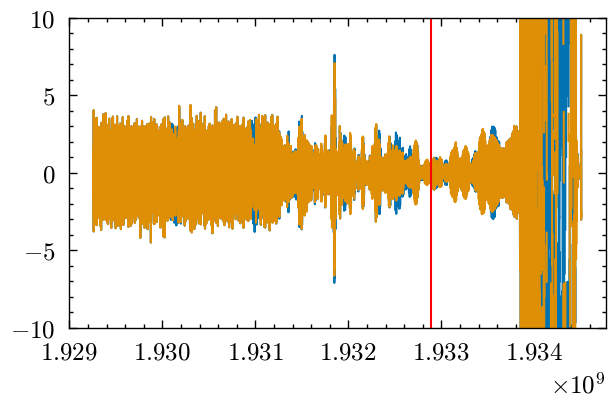

In [13]:
plt.plot(snr5_norm.sample_times, snr5_norm)
plt.plot(snr6_norm.sample_times, snr6_norm)
plt.ylim(-10,10)
# Contain the area of interest: Anything to the *right* of the red line is invalid.
INVALID_DATA_POINT = 42 # (days) This will depend on waveform cut-length and a bunch of other things
plt.plot(
    [float(snr5_norm.start_time) + INVALID_DATA_POINT*86400, float(snr5_norm.start_time) + INVALID_DATA_POINT*86400],
    [-10, 10],
    'r-'
)

float(masked_datafts_end.start_time) + 21*86400, float(masked_datafts_end.start_time) + 50*86400

In [14]:
# For plotting, we shift the SNR series to peak at 0 for consistency with other plots
# ... and then roll back by 10000 to be able to make plots that don't wraparound.
# This shift should not be applied in a real search where the time of the SNR timeseries would correspond to merger time.
snr5_norm.roll(-wform_shift)
snr5_norm.roll(10000)
snr6_norm.roll(-wform_shift)
snr6_norm.roll(10000)

### Zero-latency filter

The following cell computes the SNR using the zero-latency filter approach. This requires code from our premerger paper
https://icg-gravwaves.github.io/lisa_premerger_paper/README.html to run ... Everything else should run off of "standard" installs

This is done to assist making comparison plots later.


In [16]:
## Get the zero-latency SNR series
waveform_params_shared = {
    't_obs_start': data_length, # This is setting the data length.
    'f_lower': 0.000001,
    'low-frequency-cutoff': 0.000001, 
    'f_final': 0.2 / 2,
    'delta_f': 1 / data_length,
    'tdi': '1.5',
    't_offset': 0,
    'cutoff_deltat': 0,
}

with open(f'{premerger_paper_location}/Data/injections.json', 'r') as inj_file:
    injections = json.load(inj_file)

waveform_params = injections['0']
waveform_params.update(waveform_params_shared)


lisa_a_zero_phase_kern = generate_pre_merger_psds(
    psd_file=f'{premerger_paper_location}/PSD_Files/model_AE_TDI1_SMOOTH_optimistic.txt.gz',
    duration=data_length,
    sample_rate=0.2,
    kernel_length=17280
)

psds_for_whitening = {'LISA_A': lisa_a_zero_phase_kern['FD'], 'LISA_E': lisa_a_zero_phase_kern['FD']}

time_before = 86400*7
cutoff_time=time_before
search_time=86400
window_length=17280

filter_waveform = copy.deepcopy(waveform_params)
filter_waveform.update({
    'approximant': 'BBHX_PhenomD',
    'mode_array':[(2,2)],
    't_offset': 7365189.431698299,
})

data_dict = {}
data_dict['LISA_A'] = data_orig
data_dict['LISA_E'] = data_orig
data_dict = pre_process_data_lisa_pre_merger(
        data_dict,
        sample_rate=sample_rate,
        psds_for_whitening=psds_for_whitening,
        window_length=window_length,
        cutoff_time=cutoff_time,
        forward_zeroes=17280,
)
data_f_dict = {}
data_f_dict['LISA_A'] = data_dict['LISA_A'].to_frequencyseries()
data_f_dict['LISA_E'] = data_dict['LISA_A'].to_frequencyseries()


waveforms = generate_waveform_lisa_pre_merger(
        filter_waveform,
        psds_for_whitening,
        sample_rate=sample_rate,
        window_length=window_length,
        cutoff_time=cutoff_time,
        forward_zeroes=17280,
)

snrA = pycbc.filter.matched_filter(
        waveforms['LISA_A'],
        data_f_dict['LISA_A'],
)

snrA.roll(1050//5) # Fixes the waveform generation not being aligned above
snrA.roll(10000)

/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/BBHX_Phenom.py:287: RuntimeWarning: Input 'f_lower' is lower than the value calculated from 't_obs_start'.
  warn(err_msg, RuntimeWarning)


## Some plots

Showing that the SNR is the same as before. Especially I like the plot in the second cell.

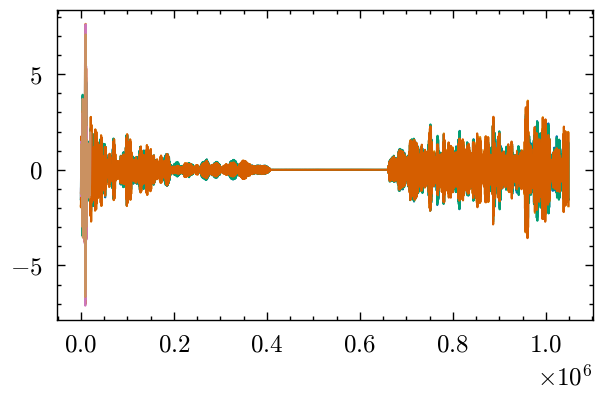

In [17]:
plt.plot(snr1)
plt.plot(snr2)
plt.plot(snr3)
plt.plot(snr4)
plt.plot(snr5_norm[:20000])
plt.plot(snr6_norm[:20000])
#plt.plot(snrA)

/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


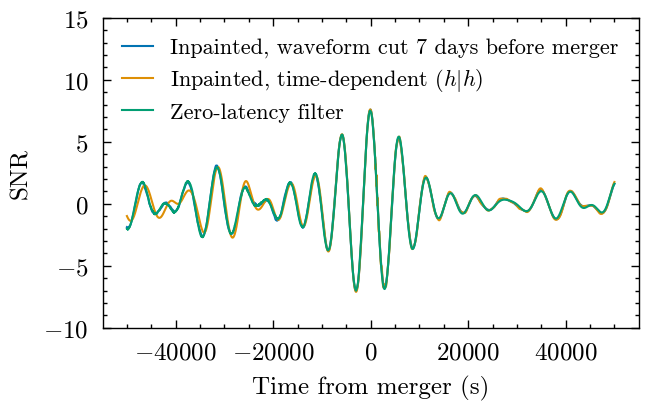

In [51]:
xvals = np.arange(20000) / sample_rate - 50000

#plt.plot(xvals, snr1[:20000], label='Inpaint and gaps')
#plt.plot(xvals, snr2[:20000], label='Inpainted (no gaps)')
#plt.plot(xvals, snr3[:20000], label='Inpaint data and gaps, wform cut')
plt.plot(xvals, snr4[:20000], label='Inpainted, waveform cut 7 days before merger')
plt.plot(xvals, snr5_norm[:20000], label='Inpainted, time-dependent $(h|h)$')
#plt.plot(xvals, snr6_norm[:20000], label='Time-dependent (gaps)')
plt.plot(xvals, snrA[:20000], label='Zero-latency filter')
plt.legend()
plt.xlabel('Time from merger (s)')
plt.ylabel(r'SNR')
#plt.xlim(0,20000)
plt.ylim(-10,15)
plt.savefig('figure_X_nogapssnrcomp.pdf')

/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


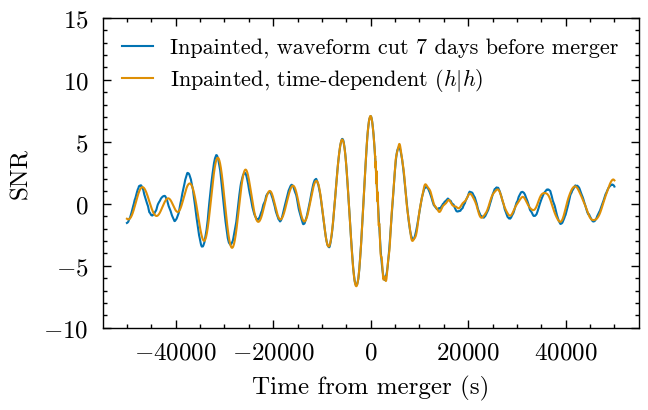

In [52]:
#plt.plot(xvals, snr1[:20000], label='Inpaint and gaps')
#plt.plot(xvals, snr2[:20000], label='Inpainted (no gaps)')
plt.plot(xvals, snr3[:20000], label='Inpainted, waveform cut 7 days before merger') # Gaps
#plt.plot(xvals, snr4[:20000], label='Inpainted, waveform cut 7 days before merger') # No gaps
#plt.plot(xvals, snr5_norm[:20000], label='Inpainted, time-dependent $(h|h)$') # Gaps
plt.plot(xvals, snr6_norm[:20000], label='Inpainted, time-dependent $(h|h)$') # No gaps
#plt.plot(xvals, snrA[:20000], label='Zero-latency filter (without gaps)')
plt.legend()
plt.xlabel('Time from merger (s)')
plt.ylabel(r'SNR')
#plt.xlim(0,20000)
plt.ylim(-10,15)
plt.savefig('figure_X_gapssnrcomp.pdf')